In [ ]:
import os
import numpy as np
import argparse
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
import tensorflow_probability as tfp
from tensorflow.keras.applications import vgg19

import functools
import timeit

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Style Transfer Implementation

**Reference:** https://github.com/superb20/Image-Style-Transfer-Using-Convolutional-Neural-Networks

**Key Differences:**
- The content representation layer has been changed from `block5_conv2` to `block4_conv2`
- VGG19's pooling layers have been changed from `MaxPooling2D` to `AveragePooling2D`
- $M_l$ in the per layer style loss $E_l$ has been changed from a constant value of `combination_size = combination_image.shape[1] * combination_image.shape[2]` to a variable value of `M_l = x_layer.shape[0]*x_layer.shape[1]`. Note that the `combination_image` has an additional batch size first dimension, so the 1st and 2nd dimensions of `combination_image` are equivalent to the 0th and 1st dimensions of `x_layer`.
- The optimizer has been changed from `keras.optimizers.Adam(keras.optimizers.schedules.ExponentialDecay())` to L-BFGS `tfp.optimizer.lbfgs_minimize()`.
- The initial white noise image has been changed from uniform noise to Gaussian with mean 0.0 and standard deviation 1.0.

**TO-DO** Normalize based on the procedure outlined by Gatys et al. "We normalized the network by scaling the weights such that the mean activation of each convolutional filter over images and positions is equal to one."

Note: I haven't implemented this because I'm not sure when this normalization is applied. Do we normalize the weights of our content and style representations? Or do we normalize the entire model beforehand?

User Input (script arguments)

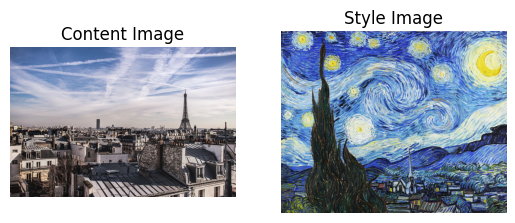

In [ ]:
# LOAD IN IMAGES

cwd = "/content/drive/MyDrive/Master's/Second Year Grad/CV/CV Final Project/code/dataset/"

content_path = cwd + 'paris.jpg' #'washsqpk.jpg'
style_path = cwd + 'starry_night.jpg' #'mona_lisa.jpg'
save_dir = cwd + 'res.png'

fig, axs = plt.subplots(1, 2)

axs[0].set_title('Content Image')
axs[1].set_title('Style Image')

axs[0].axis('off')
axs[1].axis('off')
axs[0].imshow(plt.imread(content_path))
axs[1].imshow(plt.imread(style_path))
plt.show()

In [ ]:
# USER INPUT

# final image size
RESIZE_HEIGHT = 607

# parameters
CONTENT_WEIGHT = 8e-4
STYLE_WEIGHT = 1

CONTENT_LAYER = "block4_conv2"
STYLE_LAYERS = ["block1_conv1",
                "block2_conv1",
                "block3_conv1",
                "block4_conv1",
                "block5_conv1"]

In [ ]:
# check GPU availability
print(f"Number of available GPUs: {len(tf.config.list_physical_devices('GPU'))}")

# resize images
img_width, img_height = keras.utils.load_img(content_path).size
RESIZE_WIDTH = int(img_width * RESIZE_HEIGHT / img_height)
print(f"Result Resolution: ({RESIZE_HEIGHT:d} x {RESIZE_WIDTH:d})")

Number of available GPUs: 1
Result Resolution: (607 x 910)


Helper Functions

In [ ]:
def get_model():
    # load in VGG19 without fully-connected layers
    model = vgg19.VGG19(weights='imagenet',
                        include_top=False)

    # replace max pooling with average pooling
    output_dict = {}
    input_layer, *layers = model.layers
    x = input_layer.output
    output_dict[input_layer.name] = x

    for layer in layers:
        if isinstance(layer, keras.layers.MaxPooling2D):
            layer = keras.layers.AveragePooling2D(
                pool_size=layer.pool_size,
                strides=layer.strides,
                padding=layer.padding,
                data_format=layer.data_format,
                name=f"{layer.name}_avg"
            )

        x=layer(x)
        output_dict[layer.name] = x

    # NORMALIZE TO-DO

    # model returns activation value for every layer as a dictionary
    return keras.Model(inputs=model.input, outputs=output_dict)


def preprocess(img_path, height, width):
    img = keras.utils.load_img(img_path, target_size=(height, width))
    arr = keras.utils.img_to_array(img)
    # add in expected batch size dimension
    arr = np.expand_dims(arr, axis=0)
    # converts from RGB to BGR
    processed = vgg19.preprocess_input(arr)
    return tf.convert_to_tensor(processed)

def compute_loss(x, content_features, style_features):
    x_features = model(x)
    content_loss = compute_content_loss(content_features, x_features)
    style_loss = compute_style_loss(style_features, x_features)
    loss = CONTENT_WEIGHT*content_loss + STYLE_WEIGHT*style_loss
    return loss

def compute_content_loss(content_features, x_features):
    F = x_features[CONTENT_LAYER]
    P = content_features[CONTENT_LAYER]
    # 1/2 * sum of squared error
    return (1/2) * tf.reduce_sum(tf.square(F-P))

def compute_style_loss(style_features, x_features):
    loss = 0
    weight = 1/len(STYLE_LAYERS) # 1/5 in Gatys et al.

    for layer in STYLE_LAYERS:
        s_layer = style_features[layer][0]
        x_layer = x_features[layer][0]

        G = gram_mat(s_layer)
        A = gram_mat(x_layer)

        N_l, M_l = x_layer.shape[-1], x_layer.shape[0]*x_layer.shape[1]
        M_l = np.max([M_l, 1e-9]) # making sure it's not zero
        E_l = 1/(4*(N_l**2)*(M_l**2)) * tf.reduce_sum(tf.square(G-A))
        loss += weight * E_l

    return loss

def gram_mat(x):
    M_l, N_l = tf.shape(x)[0]*tf.shape(x)[1], tf.shape(x)[2]
    F = tf.reshape(x, (M_l, N_l))
    return tf.matmul(tf.transpose(F), F)

def save_img(res_img, save_name = save_dir):
    img = res_img.numpy()
    img = img.reshape((RESIZE_HEIGHT, RESIZE_WIDTH, 3))

    # vgg19 de-processing
    # undoing zero-center by mean
    img[:,:,0] += 103.939
    img[:,:,1] += 116.779
    img[:,:,2] += 123.680
    # BGR to RGB
    img = img[:,:,::-1]
    keras.utils.save_img(save_name, np.clip(img, 0, 255).astype("uint8"))

Main

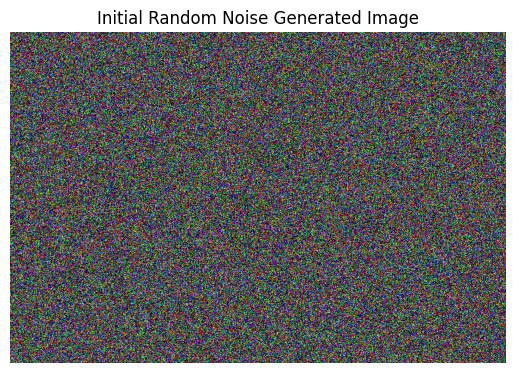

In [ ]:
# pre-processing
content_tensor = preprocess(content_path, RESIZE_HEIGHT, RESIZE_WIDTH)
style_tensor = preprocess(style_path, RESIZE_HEIGHT, RESIZE_WIDTH)

# random noise result image initialization
gen_img = tf.Variable(tf.random.normal(style_tensor.shape,
                      mean=0.0, stddev=1.0,
                      dtype=tf.dtypes.float32))

plt.figure()
plt.title(f'Initial Random Noise Generated Image')
plt.axis('off')
plt.imshow(np.clip(gen_img.numpy().reshape((RESIZE_HEIGHT, RESIZE_WIDTH, 3)), 0, 1))
plt.show()

In [ ]:
# initialize model
model = get_model()
print(model.summary())

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, None, None, 3)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, None, None, 64)      │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, None, None, 64)      │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool_avg (AveragePooling2D)   │ (None, None, None, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, None, None, 128)     │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, None, None, 128)     │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool_avg (AveragePooling2D)   │ (None, None, None, 128)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, None, None, 256)     │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool_avg (AveragePooling2D)   │ (None, None, None, 256)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, None, None, 512)     │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool_avg (AveragePooling2D)   │ (None, None, None, 512)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
content_features = model(content_tensor)
style_features = model(style_tensor)

# L-BFGS optimization
compute_loss_partial = functools.partial(compute_loss,
                                          content_features = content_features,
                                          style_features = style_features)

start = timeit.default_timer()
optim_results = tfp.optimizer.lbfgs_minimize(
    lambda x: tfp.math.value_and_gradient(compute_loss_partial, x),
    initial_position=gen_img,
    tolerance = 1e-10)
end = timeit.default_timer()

res_img = optim_results.position

print(f'Total Elapsed Time = {end-start}')

Total Elapsed Time = 114.73868731500002


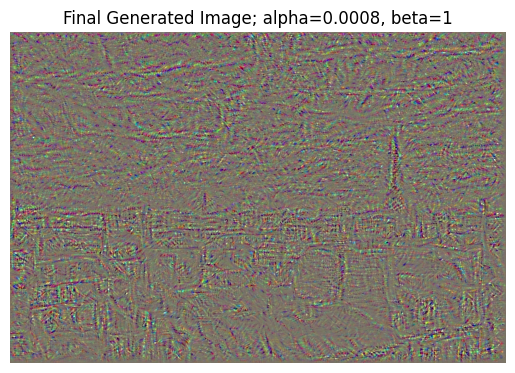

In [ ]:
# save and display results
#save_img(res_img)

res_img = res_img.numpy()
res_img = res_img.reshape((RESIZE_HEIGHT, RESIZE_WIDTH, 3))

# vgg19 de-processing
# undoing zero-center by mean
res_img[:,:,0] += 103.939
res_img[:,:,1] += 116.779
res_img[:,:,2] += 123.680
# BGR to RGB
res_img = res_img[:,:,::-1]

res_img = np.clip(res_img, 0, 255).astype("uint8")

plt.figure()
plt.title(f'Final Generated Image; alpha={CONTENT_WEIGHT}, beta={STYLE_WEIGHT}')
plt.axis('off')
plt.imshow(res_img)
plt.show()

Extra: Comparing Against Adam Optimizer

In [ ]:
NUM_ITER = 1000

optimizer = keras.optimizers.Adam(learning_rate=5.0)

# Track best results
best_loss, best_img = float('inf'), None

# Optimize result image
for iter in range(NUM_ITER):
    with tf.GradientTape() as tape:
        loss = compute_loss(gen_img, content_features, style_features)

    if loss < best_loss:
        best_loss = loss
        best_img = gen_img.numpy()

    grads = tape.gradient(loss, gen_img)
    optimizer.apply_gradients([(grads, gen_img)])

    if iter % 100 == 0:
        print("iter: %4d, loss: %8.f" % (iter, loss))

iter:    0, loss: 655142592
iter:  100, loss: 63964568
iter:  200, loss: 54590912
iter:  300, loss: 52035408
iter:  400, loss: 50988056
iter:  500, loss: 50585964
iter:  600, loss: 49981016
iter:  700, loss: 49753636
iter:  800, loss: 49487976
iter:  900, loss: 49531096


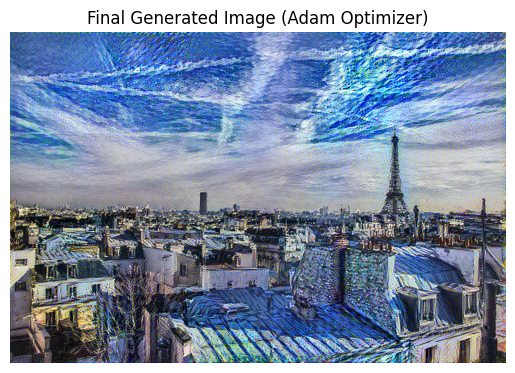

In [ ]:
test_img = best_img.reshape((RESIZE_HEIGHT, RESIZE_WIDTH, 3))

# vgg19 de-processing
# undoing zero-center by mean
test_img[:,:,0] += 103.939
test_img[:,:,1] += 116.779
test_img[:,:,2] += 123.680
# BGR to RGB
test_img = test_img[:,:,::-1]

test_img = np.clip(test_img, 0, 255).astype("uint8")

plt.figure()
plt.title(f'Final Generated Image (Adam Optimizer)')
plt.axis('off')
plt.imshow(test_img)
plt.show()